# Using transfer learning to classify one image

In [ ]:
!pip install tensorflow_hub

In [4]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [5]:
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [6]:
# Load model
mobilenet_v2 ="https://tfhub.dev/google/tf2-preview/mobilenet_v2/classification/4"
classifier_model = mobilenet_v2

In [7]:
# Define model
IMAGE_SHAPE = (224, 224)

classifier = tf.keras.Sequential([
    hub.KerasLayer(classifier_model, input_shape=IMAGE_SHAPE+(3,))
])

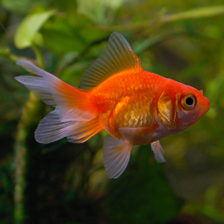

In [16]:
# load image
import PIL.Image as Image
gold_fish = Image.open("goldfish.jpg").resize(IMAGE_SHAPE)
gold_fish

In [15]:
# Get predicted class label index of the image
import numpy as np
gold_fish = np.array(gold_fish)/255.0
result = classifier.predict(gold_fish[np.newaxis, ...])
predicted_label_index = np.argmax(result)
predicted_label_index

1/1 [==============================] - 1s 737ms/step


np.int64(2)

In [11]:
# Read the image labels file and store the labels in a list
image_labels = []
with open("ImageNetLabels.txt", "r") as f:
    image_labels = f.read().splitlines()

image_labels[:3]

['background', 'tench', 'goldfish']

In [17]:
# Fetch label name from index and display label to which the image belongs too
image_labels[predicted_label_index]

'goldfish'

# Load flowers dataset

In [8]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, cache_dir='.', untar=True)

228813984/228813984 [==============================] - 2s 0us/step


In [9]:
# Set dataset path
import pathlib
data_dir = pathlib.Path(data_dir)
data_dir

PosixPath('datasets/flower_photos')

In [10]:
# Storing image file paths in a dict
flowers_images_dict = {
    'roses': list(data_dir.glob('**/roses/*')),
    'daisy': list(data_dir.glob('**/daisy/*')),
    'dandelion': list(data_dir.glob('**/dandelion/*')),
    'sunflowers': list(data_dir.glob('**/sunflowers/*')),
    'tulips': list(data_dir.glob('**/tulips/*')),
}

In [11]:
# Defining labels
flowers_labels_dict = {
    'roses':0,
    'daisy':1,
    'dandelion':2,
    'sunflowers':3,
    'tulips':4,
}

In [12]:
# Defining X, such that X contains array representation of image and Y contains the image label
import cv2
X, y = [], []

for flower_name, images in flowers_images_dict.items():
  for image in images:
    img = cv2.imread(str(image))
    resized_img = cv2.resize(img,(180,180))
    X.append(resized_img)
    y.append(flowers_labels_dict[flower_name])

In [13]:
# Converting into numpy arrays
import numpy as np
X = np.array(X)
y = np.array(y)

In [14]:
# Scaling
X = X/255

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y)

# Prediction without pre-training

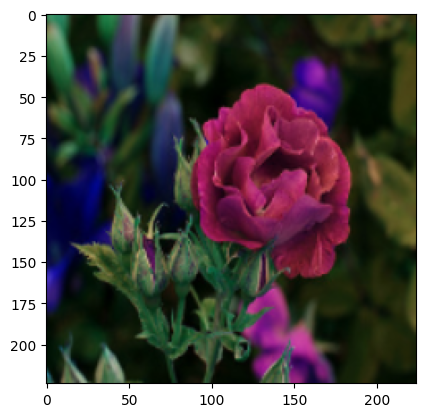

In [66]:
import matplotlib.pyplot as plt
x0 = cv2.resize(X[25], IMAGE_SHAPE)
plt.imshow(x0)

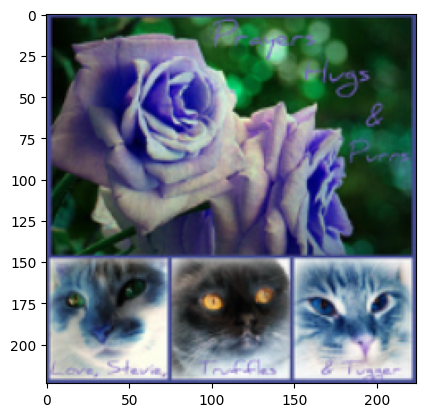

In [30]:
x1 = cv2.resize(X[100], IMAGE_SHAPE)
plt.imshow(x1)

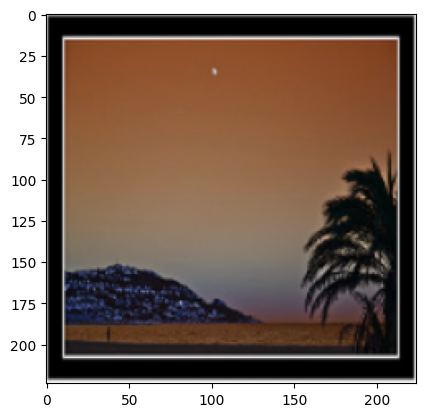

In [33]:
x2 = cv2.resize(X[501], IMAGE_SHAPE)
plt.imshow(x2)

In [67]:
predicted = classifier.predict(np.array([x0, x1, x2]))
predicted_i = np.argmax(predicted, axis=1)
predicted_i

1/1 [==============================] - 0s 116ms/step


array([992, 286, 979])

In [68]:
image_labels[992]

'coral fungus'

In [42]:
image_labels[286]

'Egyptian cat'

In [44]:
image_labels[979]

'seashore'

# Prediction with pre-training

In [16]:
feature_extractor_model = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"

pretrained_model = hub.KerasLayer(
    feature_extractor_model, input_shape=(224, 224, 3), trainable=False
)

In [17]:
with tf.device('/GPU:0'):
  model = tf.keras.Sequential([
    layers.Resizing(IMAGE_SHAPE[0], IMAGE_SHAPE[1]),
    pretrained_model,
    layers.Dense(5)
  ])

  model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
  )

  model.fit(X_train, y_train, epochs=5)

Epoch 1/5
86/86 [==============================] - 12s 36ms/step - loss: 0.8561 - accuracy: 0.6799
Epoch 2/5
86/86 [==============================] - 3s 37ms/step - loss: 0.4426 - accuracy: 0.8470
Epoch 3/5
86/86 [==============================] - 3s 37ms/step - loss: 0.3430 - accuracy: 0.8939
Epoch 4/5
86/86 [==============================] - 3s 37ms/step - loss: 0.2888 - accuracy: 0.9099
Epoch 5/5
86/86 [==============================] - 3s 37ms/step - loss: 0.2531 - accuracy: 0.9226


In [18]:
model.evaluate(X_test, y_test)

29/29 [==============================] - 2s 51ms/step - loss: 0.4030 - accuracy: 0.8551


[0.4029810428619385, 0.8551198244094849]

In [19]:
y_pred = model.predict(X_test)
y_pred_i = np.argmax(y_pred, axis=1)

29/29 [==============================] - 2s 37ms/step


In [21]:
y_pred_i[:5]

array([0, 2, 0, 0, 2])

In [22]:
y_test[:5]

array([0, 2, 0, 0, 2])

<Axes: >

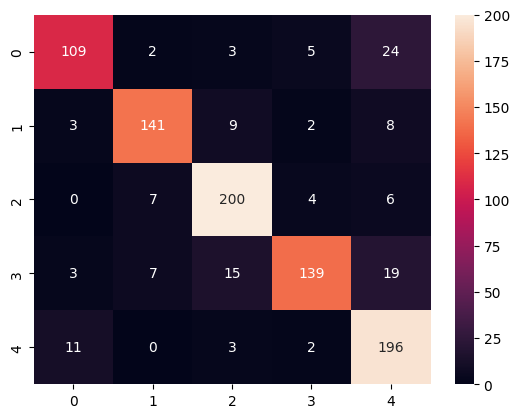

In [23]:
import seaborn as sns
cm = tf.math.confusion_matrix(labels=y_test, predictions=y_pred_i)
sns.heatmap(cm, annot=True, fmt='d')

In [24]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_i))

              precision    recall  f1-score   support

           0       0.87      0.76      0.81       143
           1       0.90      0.87      0.88       163
           2       0.87      0.92      0.89       217
           3       0.91      0.76      0.83       183
           4       0.77      0.92      0.84       212

    accuracy                           0.86       918
   macro avg       0.86      0.85      0.85       918
weighted avg       0.86      0.86      0.85       918

